<a id='table_of_contents'></a>

0. [Import libraries](#imports)
1. [Import data](#import_data)
2. [Data exploration](#data_exploration)
3. [Data cleaning](#data_cleaning)
4. [Data preparation](#data_preparation)
5. [Benchmark model](#benchmark_model)<br>
6. [Feature engineering](#feature_engineering)
7. [Model training](#model_training)<br>
    7.1. [Decision Tree](#decision_tree)<br>
    7.2. [Random Forest](#random_forest)<br>
    7.3. [Comparing algorithm performances](#comparing_algorithm_performances)
8. [Tuning](#tuning)<br>

# 0. Import libraries <a id='imports'></a>

[Back to top](#table_of_contents)

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline

# 1. Import data <a id='import_data'></a>
[Back to top](#table_of_contents)

In [2]:
taxi_data_jan_2025 = pd.read_parquet(r'data/yellow_tripdata_2020-01.parquet',engine='pyarrow')
taxi_df = pd.concat([taxi_data_jan_2025])

In [3]:
print(taxi_df.shape)
taxi_df.head()

(6405008, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,None
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,None
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,None
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,None
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,None


# 2. Data exploration <a id='data_exploration'></a>
[Back to top](#table_of_contents)

In [4]:
taxi_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [5]:
taxi_df.shape

(6405008, 19)

In [6]:
taxi_df = taxi_df[['tpep_pickup_datetime', 'tpep_dropoff_datetime','passenger_count',
                   'trip_distance', 'RatecodeID','PULocationID', 'DOLocationID',
                   'payment_type', 'total_amount']]

In [7]:
taxi_df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,238,239,1,11.27
1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,239,238,1,12.30
2,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,238,238,1,10.80
3,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,238,151,1,8.16
4,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,193,193,2,4.80


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>]], dtype=object)

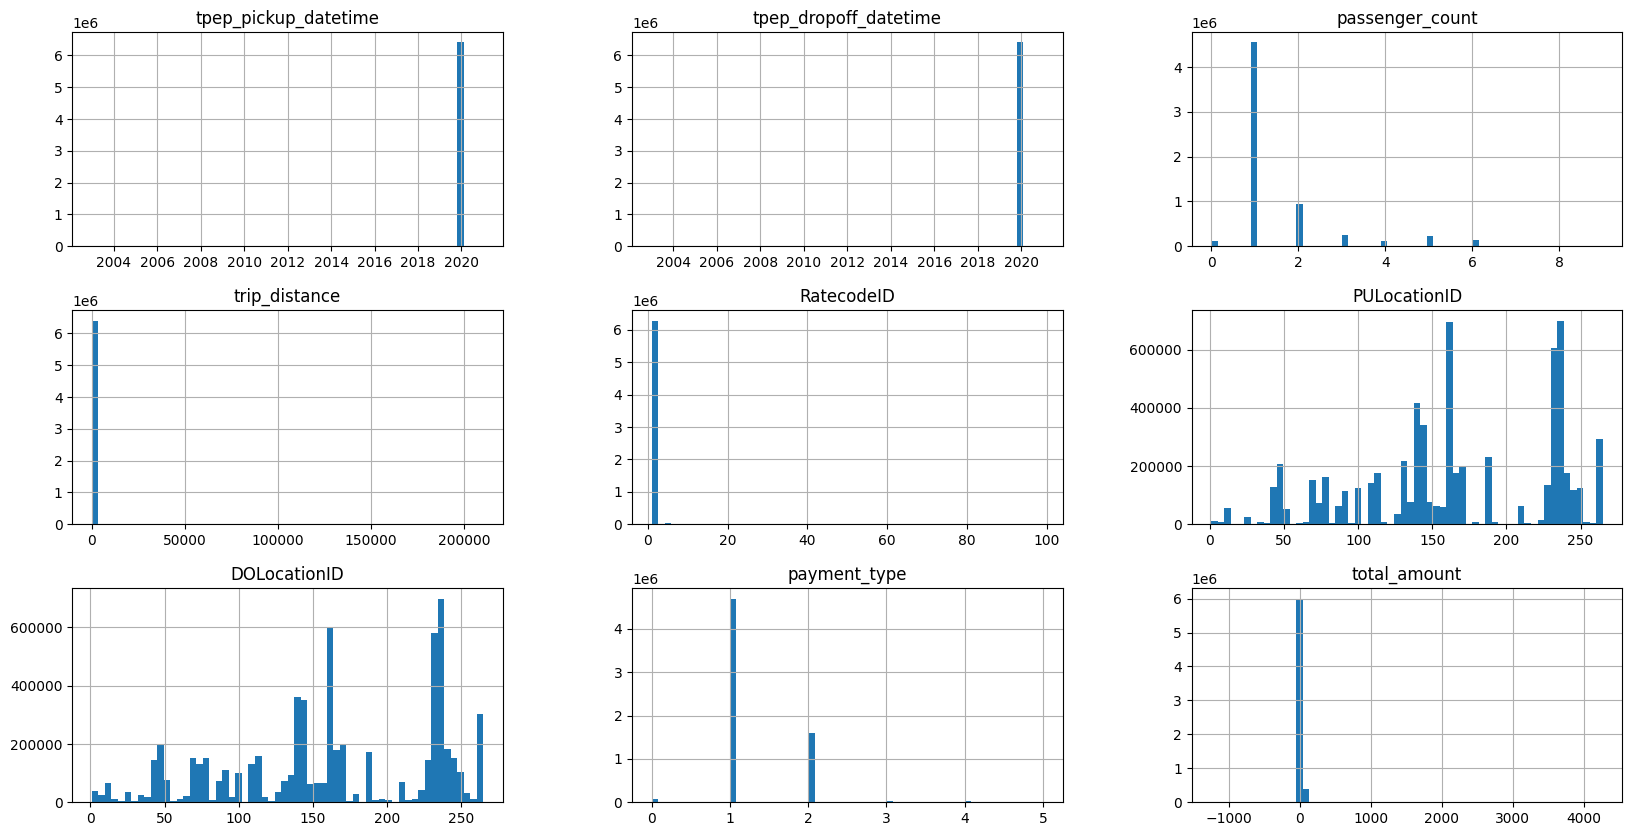

In [8]:
taxi_df.hist(figsize=(20,10),bins=60)

payment_type
4    8844
3    6985
2    3593
0      64
1      19
Name: count, dtype: int64


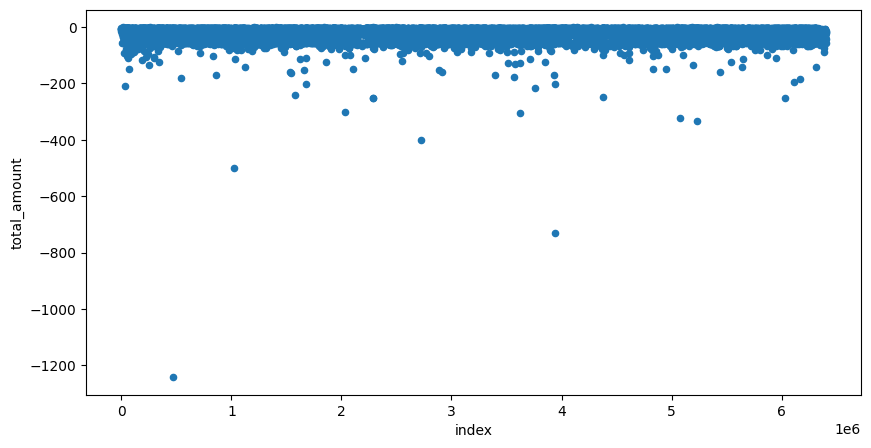

In [9]:
taxi_df[taxi_df['total_amount']<0].reset_index().plot(kind='scatter',y='total_amount',x='index',figsize=(10,5))
print(taxi_df[taxi_df['total_amount']<0]['payment_type'].value_counts())

We can safely ignore negative amounts as we can see most of it are disputes(payment type 4) or payment with cash.
Zero values can also be ignored because most of those have a trip distance of 0(meaning it's the result of canceled trips)

trip_distance
0.00    1044
0.01      37
0.02      19
0.10      16
0.03      14
        ... 
3.34       1
9.71       1
9.54       1
3.40       1
1.09       1
Name: count, Length: 356, dtype: int64


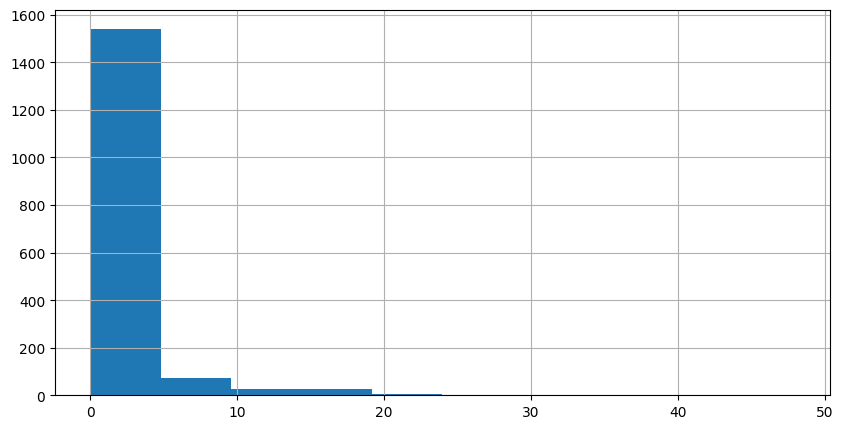

In [10]:
taxi_df[taxi_df['total_amount']==0]['trip_distance'].hist(figsize=(10,5),bins=10)
print(taxi_df[taxi_df['total_amount']==0]['trip_distance'].value_counts())

In [11]:
taxi_df[taxi_df['total_amount']>200].shape

(1197, 9)

As we can see, out of the 3475226 entries we have 1913 entries with a total amount that is more than 200 dollars, so we can say those are outliers and shouldn't weight in our research

# 3. Data cleaning <a id='data_cleaning'></a>
[Back to top](#table_of_contents)

<Axes: xlabel='index', ylabel='total_amount'>

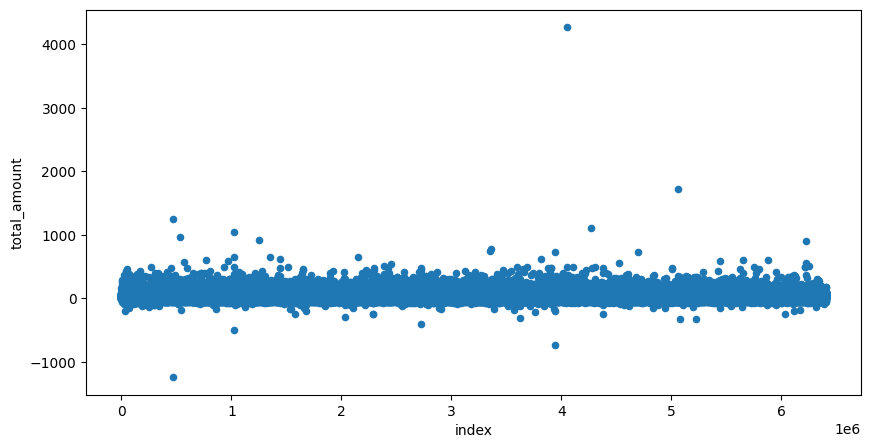

In [12]:
taxi_df.reset_index().plot(kind='scatter',y='total_amount',x='index',figsize=(10,5))

In [13]:
max_amount = taxi_df['total_amount'].max()
print(max_amount)

4268.3


In [14]:
taxi_df.isna().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          65441
trip_distance                0
RatecodeID               65441
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
dtype: int64

In [15]:
taxi_df.passenger_count.value_counts(dropna=False)

passenger_count
1.0    4547226
2.0     946423
3.0     250234
5.0     225693
6.0     132154
4.0     123470
0.0     114302
NaN      65441
7.0         29
9.0         19
8.0         17
Name: count, dtype: int64

there is very few data with NaN values, it should be an error while reading the parquet, but as for now i can't find the answer so we avoid that data.

In [16]:
taxi_df.dropna(inplace=True)

# 4. Data preparation <a id='data_preparation'></a>
[Back to top](#table_of_contents)

In [17]:
taxi_df.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
dtype: object

In [18]:
taxi_df_prepared =taxi_df.copy()

In [19]:
taxi_df_prepared.loc[:,'RatecodeID']= taxi_df_prepared['RatecodeID'].astype(str)
taxi_df_prepared.loc[:,'payment_type']= taxi_df_prepared['payment_type'].astype(str)
taxi_df_prepared.loc[:,'PULocationID']= taxi_df_prepared['PULocationID'].astype(str)
taxi_df_prepared.loc[:,'DOLocationID']= taxi_df_prepared['DOLocationID'].astype(str)
taxi_df_prepared.loc[:,'passenger_count']=taxi_df_prepared['passenger_count'].astype('int64')

/var/folders/6b/05qv97gd56945b775snlycyw0000gn/T/ipykernel_5632/236489951.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1.0' '1.0' '1.0' ... '1.0' '1.0' '1.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  taxi_df_prepared.loc[:,'RatecodeID']= taxi_df_prepared['RatecodeID'].astype(str)
/var/folders/6b/05qv97gd56945b775snlycyw0000gn/T/ipykernel_5632/236489951.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1' '1' '1' ... '1' '2' '1']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  taxi_df_prepared.loc[:,'payment_type']= taxi_df_prepared['payment_type'].astype(str)
/var/folders/6b/05qv97gd56945b775snlycyw0000gn/T/ipykernel_5632/236489951.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of p

In [20]:
taxi_df_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,238,239,1,11.27
1,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,239,238,1,12.30
2,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,238,238,1,10.80
3,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,238,151,1,8.16
4,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,193,193,2,4.80


In [21]:
taxi_df_prepared['transaction_date'] = pd.to_datetime(taxi_df_prepared['tpep_pickup_datetime'].dt.date)
taxi_df_prepared['transaction_year'] = taxi_df_prepared['tpep_pickup_datetime'].dt.year
taxi_df_prepared['transaction_month'] = taxi_df_prepared['tpep_pickup_datetime'].dt.month
taxi_df_prepared['transaction_day'] = taxi_df_prepared['tpep_pickup_datetime'].dt.day
taxi_df_prepared['transaction_hour'] = taxi_df_prepared['tpep_pickup_datetime'].dt.hour

In [22]:
taxi_df_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                       object
PULocationID                     object
DOLocationID                     object
payment_type                     object
total_amount                    float64
transaction_date         datetime64[ns]
transaction_year                  int32
transaction_month                 int32
transaction_day                   int32
transaction_hour                  int32
dtype: object

In [23]:
taxi_df_prepared.transaction_year.value_counts()

transaction_year
2020    6339403
2019        131
2009         19
2008         10
2021          3
2003          1
Name: count, dtype: int64

While preparing the data we discovered that there must be some error in the dates, this dataset is for january of 2020, there can't be values other than 2020 so we have to clean it.

In [24]:
taxi_df_prepared = taxi_df_prepared[taxi_df_prepared['transaction_year']==2020]
taxi_df_prepared = taxi_df_prepared[taxi_df_prepared['transaction_month']==1]

In [25]:
categorical_columns = ['PULocationID','transaction_date','transaction_month','transaction_day','transaction_hour']
numerical_columns = ['trip_distance','total_amount']
all_needed_columns = categorical_columns + numerical_columns

In [26]:
main_taxi_df = taxi_df_prepared[all_needed_columns]
main_taxi_df.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount
0,238,2020-01-01,1,1,0,1.2,11.27
1,239,2020-01-01,1,1,0,1.2,12.30
2,238,2020-01-01,1,1,0,0.6,10.80
3,238,2020-01-01,1,1,0,0.8,8.16
4,193,2020-01-01,1,1,0,0.0,4.80


In [27]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_grouped_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['total_amount']
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2020-01-01,1,1,3,0.0,95.30,1
1,1,2020-01-01,1,1,4,0.0,94.80,1
2,1,2020-01-01,1,1,5,0.0,40.30,1
3,1,2020-01-01,1,1,6,0.0,111.32,4
4,1,2020-01-01,1,1,7,0.0,0.31,1


# 5. Benchmark model <a id='benchmark_model'></a>
[Back to top](#table_of_contents)

In [28]:
data_benchmark_model= taxi_grouped_by_region.copy()

In [29]:
categorical_columns_benchmark = ['PULocationID', 'transaction_month','transaction_day','transaction_hour']
input_columns_benchmark = categorical_columns_benchmark
output_columns_benchmark = 'total_amount'                

# 5.1 Train-test

In [30]:
from sklearn.model_selection import train_test_split
x_bench =data_benchmark_model[input_columns_benchmark]
y_bench=data_benchmark_model[output_columns_benchmark]

x_bench= pd.get_dummies(x_bench)

x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(x_bench,y_bench,test_size=0.33,random_state=42)

# 5.2 Fit a model to the data

In [31]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(x_train_b,y_train_b)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

# 5.3 Model evaluation

In [32]:
model_to_analyze = tree

y_pred_b = model_to_analyze.predict(x_test_b)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean absolute error',mean_absolute_error(y_test_b,y_pred_b))
print('mean square error',mean_squared_error(y_test_b,y_pred_b))
print('root mean squared error',sqrt(mean_squared_error(y_test_b,y_pred_b)))
print('r2 score',r2_score(y_test_b,y_pred_b))


mean absolute error 10.043126457501147
mean square error 330.75320189755047
root mean squared error 18.18662150861315
r2 score 0.251867689077231


<Axes: xlabel='true', ylabel='pred'>

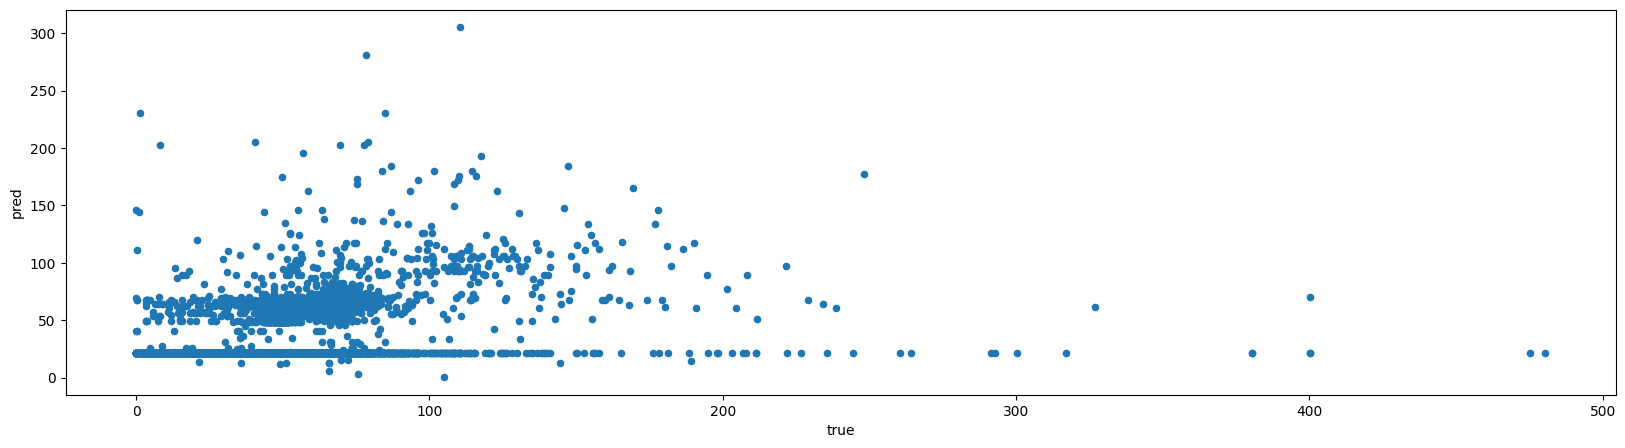

In [33]:
data = {'true':y_test_b,'pred':y_pred_b}
results =pd.DataFrame(data)

results.plot(figsize=(20,5),kind ='scatter',x='true',y='pred')

# 6. Feature engineering <a id='feature_engineering'></a>
[Back to top](#table_of_contents)

In [34]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2020-01-01,1,1,3,0.0,95.30,1
1,1,2020-01-01,1,1,4,0.0,94.80,1
2,1,2020-01-01,1,1,5,0.0,40.30,1
3,1,2020-01-01,1,1,6,0.0,111.32,4
4,1,2020-01-01,1,1,7,0.0,0.31,1


In [35]:
data_with_new_features = taxi_grouped_by_region.copy()

## Adding new features to the data

In [36]:
data_with_new_features['transaction_week_day']=data_with_new_features['transaction_date'].dt.weekday
data_with_new_features['weekend'] =data_with_new_features['transaction_week_day'].apply(lambda x: True if x==5 or x==6 else False)


In [37]:
from pandas.tseries.holiday import USFederalHolidayCalendar
calendar = USFederalHolidayCalendar()
holidays=calendar.holidays(start='2018',end='2020').date
data_with_new_features['is_holiday']=data_with_new_features['transaction_date'].isin(pd.to_datetime(holidays))
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2020-01-01,1,1,3,0.0,95.30,1,2,False,True
1,1,2020-01-01,1,1,4,0.0,94.80,1,2,False,True
2,1,2020-01-01,1,1,5,0.0,40.30,1,2,False,True
3,1,2020-01-01,1,1,6,0.0,111.32,4,2,False,True
4,1,2020-01-01,1,1,7,0.0,0.31,1,2,False,True


Borough information

In [38]:
zone_info = pd.read_csv(r'data/taxi_zone_lookup.csv')
zone_info = zone_info[['LocationID','Borough']]
zone_info['LocationID'] = zone_info['LocationID'].astype(str)
zone_info.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [39]:
data_with_new_features = data_with_new_features.merge(zone_info,left_on='PULocationID',right_on='LocationID',how='left')
data_with_new_features.drop('LocationID',axis=1,inplace=True)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2020-01-01,1,1,3,0.0,95.30,1,2,False,True,EWR
1,1,2020-01-01,1,1,4,0.0,94.80,1,2,False,True,EWR
2,1,2020-01-01,1,1,5,0.0,40.30,1,2,False,True,EWR
3,1,2020-01-01,1,1,6,0.0,111.32,4,2,False,True,EWR
4,1,2020-01-01,1,1,7,0.0,0.31,1,2,False,True,EWR


### Weather features
To enhance the model's predictive power, we integrate historical weather data. Environmental conditions, such as heavy precipitation, typically correlate with increased taxi demand and higher daily revenue. We utilize the [NYC Weather Dataset (2016–2022)](https://www.kaggle.com/datasets/aadimator/nyc-weather-2016-to-2022) to enhance our model. for this purpose. The following preprocessing steps include type casting, feature selection to retain only relevant variables, and temporal filtering to align the weather data with our taxi trip records.

In [40]:
nyc_weather= pd.read_csv(r'data/NYC_Weather_2016_2022.csv')
nyc_weather.dtypes

time                      object
temperature_2m (°C)      float64
precipitation (mm)       float64
rain (mm)                float64
cloudcover (%)           float64
cloudcover_low (%)       float64
cloudcover_mid (%)       float64
cloudcover_high (%)      float64
windspeed_10m (km/h)     float64
winddirection_10m (°)    float64
dtype: object

In [41]:
nyc_weather['time']=pd.to_datetime(nyc_weather['time'])
nyc_weather.drop(['rain (mm)', 'cloudcover_low (%)', 'cloudcover_mid (%)',
                  'cloudcover_high (%)', 'winddirection_10m (°)'],axis=1,inplace=True)

In [42]:
nyc_weather[nyc_weather['time'].dt.year==2020].head()

,time,temperature_2m (°C),precipitation (mm),cloudcover (%),windspeed_10m (km/h)
35064,2020-01-01 00:00:00,4.7,0.0,78.0,9.2
35065,2020-01-01 01:00:00,4.8,0.0,91.0,9.7
35066,2020-01-01 02:00:00,5.4,0.0,100.0,11.4
35067,2020-01-01 03:00:00,5.2,0.0,74.0,12.3
35068,2020-01-01 04:00:00,5.0,0.0,23.0,13.4


In [43]:
nyc_weather = nyc_weather[nyc_weather['time'].dt.year==2020]
nyc_weather.reset_index(drop=True,inplace=True)
nyc_weather.head()

,time,temperature_2m (°C),precipitation (mm),cloudcover (%),windspeed_10m (km/h)
0,2020-01-01 00:00:00,4.7,0.0,78.0,9.2
1,2020-01-01 01:00:00,4.8,0.0,91.0,9.7
2,2020-01-01 02:00:00,5.4,0.0,100.0,11.4
3,2020-01-01 03:00:00,5.2,0.0,74.0,12.3
4,2020-01-01 04:00:00,5.0,0.0,23.0,13.4


In [44]:
nyc_weather= nyc_weather.rename({'time':'date_time','temperature_2m (°C)':'temperature','precipitation (mm)':'precipitation',
                                 'cloudcover (%)':'cloudcover','windspeed_10m (km/h)':'windspeed'},axis=1)
nyc_weather.head()

,date_time,temperature,precipitation,cloudcover,windspeed
0,2020-01-01 00:00:00,4.7,0.0,78.0,9.2
1,2020-01-01 01:00:00,4.8,0.0,91.0,9.7
2,2020-01-01 02:00:00,5.4,0.0,100.0,11.4
3,2020-01-01 03:00:00,5.2,0.0,74.0,12.3
4,2020-01-01 04:00:00,5.0,0.0,23.0,13.4


# 7. Model training <a id='model_training'></a>
[Back to top](#table_of_contents)

## 7.1. Decision tree <a id='decision_tree'></a>

## 7.2. Random forest <a id='random_forest'></a>

## 7.3. Comparing algorithm performances <a id='comparing_algorithm_performances'></a>

# 8. Tuning <a id='tuning'></a>
[Back to top](#table_of_contents)